## Burgers Dynamics

### Configuration

In [1]:
from __init__ import create_config, figures
from IPython.display import display

config = create_config(
    system="burgers",
    n_states=32,
    n_controls=2,
    t1_initial=15.0,
    t1_max=60.0,
)
cache_dir = f"./cache_seed{config.seed}"
figures.save_config_table(config)
figures.show_spec(config, keys=["system", "seed", "n_states", "n_controls", "t1_initial"])

system,seed,n_states,n_controls,t1_initial
burgers,32,32,2,15.000000


### Data Generation

In [2]:
# Configure which controllers to enable/disable
# Use the exact names from DEFAULT_CONTROLLER_CONFIGS in model_factory.py
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup)": {"enabled": True},
    "GradQRNet (pre)": {"enabled": True},  # Hybrid (pretraining)
    "GradQRNet (ad)": {"enabled": True},  # Adaptive sampling
}

# If controller_configs is None, all defaults from model_factory.py are used
# If you provide a dict, it will merge with defaults (partial overrides are allowed)


Solving open loop OCPs...

 attempted |  solved   |  desired  
-----------------------------------


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.
capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


...

capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


trajectories,data points,t (min),t (max),|x| (mean),|x| (max),||x|| (mean),||x|| (max)
100,9404,0.000000,4.643665,0.255126,1.591490,0.475690,1.090637


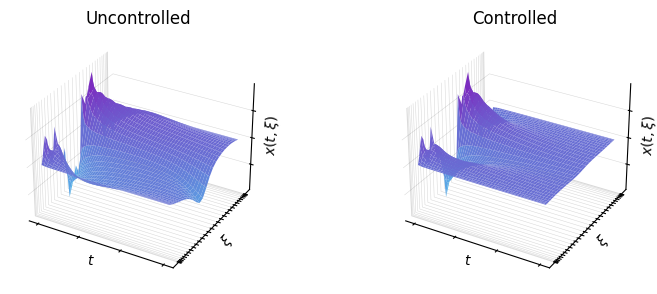

In [3]:
import matplotlib.pyplot as plt
from data import load_or_generate

data_train, data_val, meta = load_or_generate(config, n_trajectories=100, controller=config.ocp.LQR)
data = data_train  # Keep using 'data' for backward compatibility

summary_df = figures.save_data_summary_table(config, data)

display(summary_df.style.hide(axis="index"))

fig = figures.plot_3d(config=config, controller=config.ocp.LQR)
plt.show()

### Model Training

In [ ]:
from controls.train import TrainConfig

cfg = TrainConfig(batch_size=int(config.n_states), horizon=30, unsup_n_steps=70) # old: 1.0

# 1. Save to LaTeX using the new generic function
figures.save_params_table(cfg, "traincfg.tex", title="Training Configuration", config=config)

# 2. Show in Notebook using the universal show_spec
figures.show_spec(
    cfg, 
    keys=["sup_epochs", "sup_lr", "unsup_epochs", "unsup_n_steps", "unsup_lr", "horizon", "batch_size", "grad_clip"], 
    title="Training Configuration"
)

**Training Configuration**

sup_epochs,sup_lr,unsup_epochs,unsup_n_steps,unsup_lr,horizon,batch_size,grad_clip
1,0.000010,5,70,0.000500,30,32,None



Training: GradQRNet
epoch 0001 | loss=8.53e-02 | hjb=1.25e-01 | sup=0.00e+00 | bs=32 | heur=nan | val_mse=2.84e+00
epoch 0002 | loss=2.47e-02 | hjb=3.35e-02 | sup=0.00e+00 | bs=32 | heur=nan | val_mse=2.83e+00
epoch 0003 | loss=1.79e-02 | hjb=2.24e-02 | sup=0.00e+00 | bs=32 | heur=nan | val_mse=2.83e+00
epoch 0004 | loss=2.20e-02 | hjb=2.55e-02 | sup=0.00e+00 | bs=32 | heur=nan | val_mse=2.83e+00
epoch 0005 | loss=2.10e-02 | hjb=2.20e-02 | sup=0.00e+00 | bs=32 | heur=nan | val_mse=2.82e+00

Training: GradQRNet (sup)
epoch 0001 | loss=3.04e-01 | hjb=9.17e-02 | sup=7.75e-02 | bs=32 | heur=nan | val_mse=2.64e+00
epoch 0002 | loss=2.65e-01 | hjb=2.94e-02 | sup=9.43e-02 | bs=32 | heur=nan | val_mse=2.51e+00
epoch 0003 | loss=1.51e-01 | hjb=2.16e-02 | sup=6.70e-02 | bs=32 | heur=nan | val_mse=2.46e+00
epoch 0004 | loss=1.22e-01 | hjb=2.21e-02 | sup=7.81e-02 | bs=32 | heur=nan | val_mse=2.43e+00
epoch 0005 | loss=5.81e-02 | hjb=2.27e-02 | sup=7.46e-02 | bs=32 | heur=nan | val_mse=2.43e+00

T

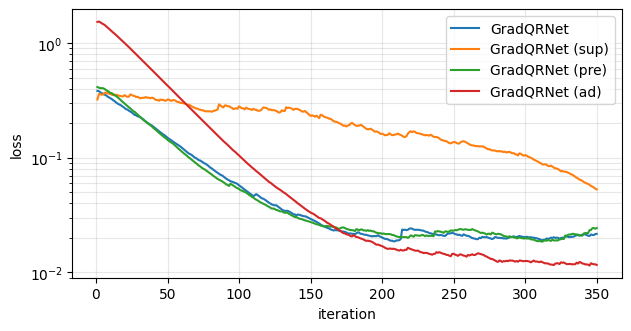

In [5]:
from controls.model_factory import train_controllers

trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
);

### Evaluation: Stability and Optimality

In [6]:
controllers = [
    ("LQR (Baseline)", config.ocp.LQR),
] + [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [7]:
from simulation import monte_carlo

results = monte_carlo(config.ocp, config, controllers, n_MC=100)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo.tex")

100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
LQR (Baseline),83.0%,0.0040,12.31,0.4323
GradQRNet,84.0%,0.0038,12.24,0.4426
GradQRNet (sup),84.0%,0.0039,12.54,0.4347
GradQRNet (pre),84.0%,0.0039,12.34,0.4320
GradQRNet (ad),86.0%,0.0030,11.73,0.4698


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,LQR (Baseline),0.83,12.311125,0.432350
1,GradQRNet,0.84,12.239728,0.442573
2,GradQRNet (sup),0.84,12.536818,0.434689
3,GradQRNet (pre),0.84,12.343964,0.431977
4,GradQRNet (ad),0.86,11.725599,0.469820


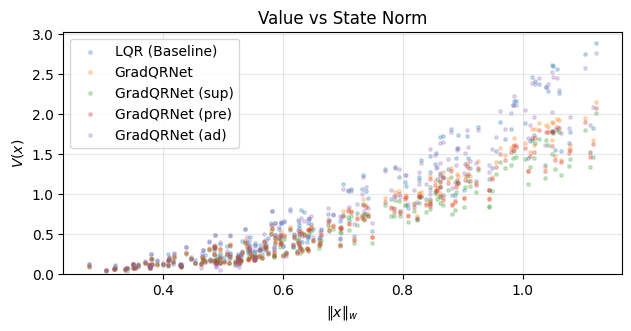

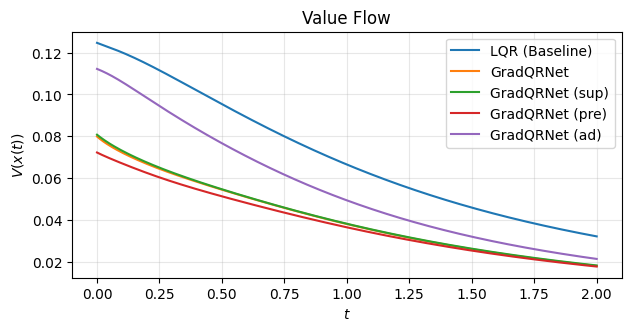

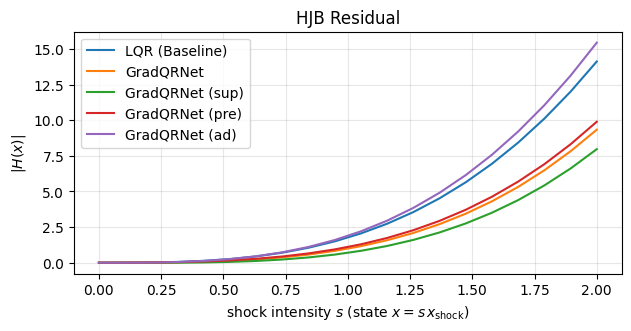

In [8]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
)
plt.show()

### Combined Architectures

In [9]:
controller_configs = {
    "GradQRNet": {"enabled": True},
    "GradQRNet (sup/ad)": {"enabled": True},
    "GradQRNet (pre/sup)": {"enabled": True},
    "GradQRNet (pre/ad)": {"enabled": True},
    "GradQRNet (pre/sup/ad)": {"enabled": True},
}


Training: GradQRNet

Training: GradQRNet (pre/sup)
epoch 0001 | loss=8.33e-01 | hjb=3.37e-01 | sup=8.33e-02 | bs=32 | heur=nan | val_mse=2.47e+00
epoch 0001 | loss=3.52e-01 | hjb=1.32e-01 | sup=8.44e-02 | bs=32 | heur=nan | val_mse=2.57e+00
epoch 0002 | loss=2.11e-01 | hjb=3.06e-02 | sup=7.26e-02 | bs=32 | heur=nan | val_mse=2.45e+00
epoch 0003 | loss=1.51e-01 | hjb=2.52e-02 | sup=6.54e-02 | bs=32 | heur=nan | val_mse=2.41e+00
epoch 0004 | loss=1.30e-01 | hjb=2.74e-02 | sup=8.11e-02 | bs=32 | heur=nan | val_mse=2.38e+00
epoch 0005 | loss=6.45e-02 | hjb=2.36e-02 | sup=7.63e-02 | bs=32 | heur=nan | val_mse=2.38e+00

Training: GradQRNet (sup/ad)
epoch 0001 | loss=4.10e-01 | hjb=2.15e-01 | sup=8.51e-02 | bs=32 | heur=nan | val_mse=2.76e+00
epoch 0002 | loss=2.37e-01 | hjb=1.74e-02 | sup=8.56e-02 | bs=32 | heur=nan | val_mse=2.68e+00
epoch 0003 | loss=2.15e-01 | hjb=6.82e-02 | sup=8.10e-02 | bs=32 | heur=nan | val_mse=2.65e+00
epoch 0004 | loss=1.63e-01 | hjb=5.99e-02 | sup=8.44e-02 | bs=3

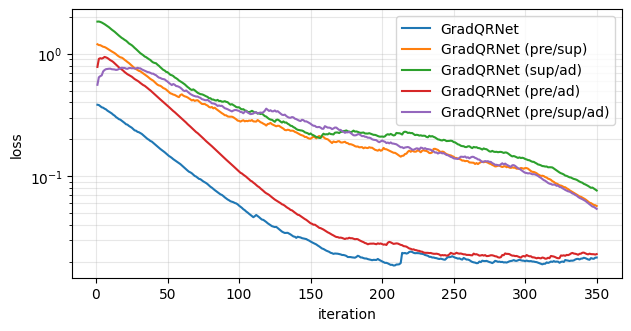

In [10]:
trained_models, trained_controllers, histories = train_controllers(
    config=config,
    train_cfg=cfg,
    data=data_train,  
    val_data=data_val,
    controller_configs=controller_configs,  # Use the config defined above
)

figures.plot_training_losses(
    config=config,
    series=[(name, hist) for name, hist in histories.items()],
    logy=True,
    smooth="ema",
    ema_alpha=0.03,
    plot_name="combined_loss_curve",
);

In [11]:
controllers = [(name, trained_controllers[name]) for name in trained_controllers.keys()]

In [12]:
results = monte_carlo(config.ocp, config, controllers, n_MC=100)
figures.show_monte_carlo_results(results)
figures.save_monte_carlo_results(results, config=config, savepath="monte_carlo_combined.tex")

  1%|          | 1/100 [00:02<03:30,  2.13s/it]

Trajectory 0 NOT converged - final_dists[0] = inf


  3%|▎         | 3/100 [00:06<02:50,  1.76s/it]

Trajectory 1 NOT converged - final_dists[1] = inf


  1%|          | 1/100 [00:04<07:10,  4.35s/it]

...

  3%|▎         | 3/100 [01:06<24:17, 15.02s/it]  

Trajectory 1 NOT converged - final_dists[1] = inf


100%|██████████| 100/100 [04:11<00:00,  2.51s/it]


Controller,Stability (S),Final ||X|| (mean),t_conv (mean),Cost J (mean)
GradQRNet,79.0%,0.0036,12.29,0.4739
GradQRNet (pre/sup),83.0%,0.0041,12.87,0.5034
GradQRNet (sup/ad),87.0%,0.0030,12.56,0.5647
GradQRNet (pre/ad),78.0%,0.0039,12.28,0.4738
GradQRNet (pre/sup/ad),80.0%,0.0037,12.45,0.5044


,Model,Stability $S$,$t_{\text{conv}}$ (mean),Cost $J$ (mean)
0,GradQRNet,0.79,12.285789,0.473931
1,GradQRNet (pre/sup),0.83,12.870398,0.503382
2,GradQRNet (sup/ad),0.87,12.558697,0.564700
3,GradQRNet (pre/ad),0.78,12.282265,0.473790
4,GradQRNet (pre/sup/ad),0.80,12.445342,0.504353


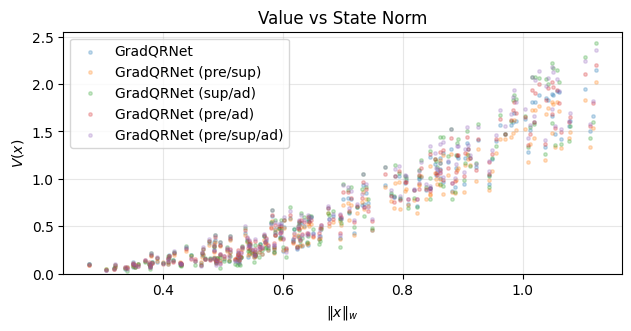

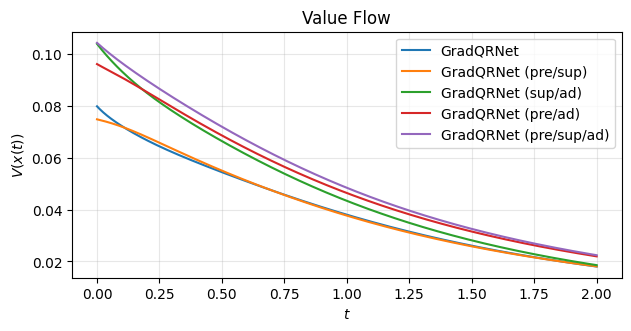

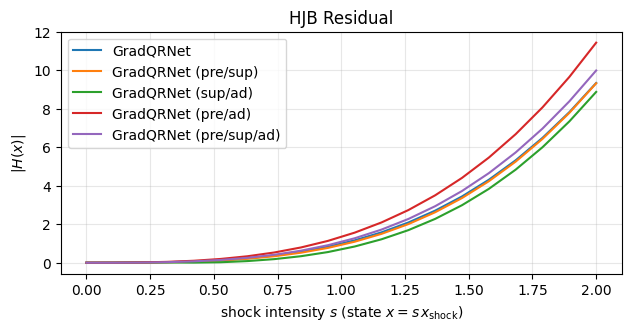

In [13]:
figures.plot_value_analysis_combined(
    config=config,
    controllers=controllers,
    n=200,
    tspan=(0.0, 2.0),
    Nt=400,
    suffix="_2",
)
plt.show()